<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
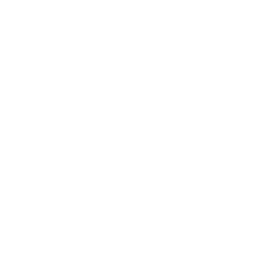
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Neljännesvuosittaisen ilmoittautumisen interpolointi kuukausitasolle</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lääketeollisuus / Kliininen toiminta &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Tiivistelmä johdolle

Tässä käytännön esimerkissä muunnetaan **neljännesvuosittaiset** kliinisen tutkimuksen ilmoittautumislukumäärät **kuukausittaisiksi** arvioiksi PROC EXPAND -toiminnolla, jotta tutkimuskeskustason resurssisuunnittelu voidaan tehdä kuukausittaisella tahdilla. Synteettinen tutkimus kattaa **neljä tutkijakeskusta** kahdella alueella (Pohjois-Amerikka ja Eurooppa) **kahdeksan neljänneksen** ajalta (Q1 2024 – Q4 2025), mikä tuottaa **32 neljännesvuosittaista havaintoa**. PROC EXPAND interpoloi kunkin keskuksen aikasarjan neljännesvuosittaisesta kuukausittaiseen frekvenssiin ja muuntaa nämä 32 neljännesvuosittaista riviä **96 kuukausittaiseksi riviksi**. Ilmoittautumislukumäärät interpoloidaan menetelmällä `METHOD=JOIN` (paloittain lineaarinen, joka pitää jokaisen arvion ei-negatiivisena) ja juokseva kumulatiivinen summa interpoloidaan menetelmällä `METHOD=SPLINE`. Interpoloitu kuukausittainen aikasarja kulkee täsmälleen alkuperäisten neljännesvuosittaisten ankkuripisteiden kautta, joten muunnos lisää neljänneksen sisäistä yksityiskohtaa muuttamatta tutkimuksen jo raportoimia neljännesvuosittaisia lukuja.

## Tietolähteet

| Lähde | Kuvaus | Tietueet |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Neljännesvuosittaiset ilmoittautumislukumäärät keskuksittain (4 keskusta x 8 neljännestä) | 32 |
| WORK.SITE_MASTER | Keskuksen viitetiedot: nimi, maa, alue, päätutkija | 4 |

---

In [1]:
/* --------------------------------------------------------
   Generate quarterly enrollment counts by site.
   4 sites x 8 quarters (Q1-2024 through Q4-2025) = 32 rows.
   A ramp-up curve (slow start, plateau) plus a mild seasonal
   term and small noise produces a realistic enrollment shape.
   -------------------------------------------------------- */
TIEDOT work.enrollment_qtr;
    PITUUS region $20;
    CALL streaminit(42);
    MUOTO quarter_date yyq7.;
    TAULUKKO capacity[4] _temporary_ (12 9 14 8);
    TEE site_num = 1 ASTI 4;
        site_id = cat('SITE-', KIRJOITA(site_num, z3.));
        region  = ifc(site_num <= 2, 'POHJOIS_AMERIKKA', 'EUROOPPA');
        base_rate = capacity[site_num];
        TEE qtr_seq = 0 ASTI 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            TULOSTE;
        LOPPU;
    LOPPU;
    POISTA site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
SUORITA;

/* Running cumulative enrollment within each site */
PROSEDUURI LAJITTELE TIEDOT=work.enrollment_qtr;
    MUKAAN site_id quarter_date;
SUORITA;

TIEDOT work.enrollment_qtr;
    ASETA work.enrollment_qtr;
    MUKAAN site_id;
    PIDÄ cum_enrolled 0;
    JOS first.site_id NIIN cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    POISTA cum_enrolled;
SUORITA;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Site master reference table (4 sites, 2 regions)
   -------------------------------------------------------- */
TIEDOT work.site_master;
    PITUUS site_id $8 site_name $40 region $20 country $20 pi_name $30;
    TAULUKKO names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    TAULUKKO countries[4] $20 _temporary_ ('Yhdysvallat' 'Yhdysvallat' 'Iso-Britannia' 'Saksa');
    TEE i = 1 ASTI 4;
        site_id   = cat('SITE-', KIRJOITA(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'POHJOIS_AMERIKKA', 'EUROOPPA');
        pi_name   = cat('Tri Tutkija-', KIRJOITA(i, z2.));
        TULOSTE;
    LOPPU;
    POISTA i;
SUORITA;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline quarterly enrollment summary by region
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.enrollment_qtr n sum mean MAX;
    LUOKKA region;
    MUUTTUJA enrolled_count cumulative_enrolled;
    NIMIKE region='Alue' enrolled_count='Ilmoittautuneet' cumulative_enrolled='Kumulatiivinen ilmoittautuminen';
    TULOSTE out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.qtr_baseline noobs NIMIKE;
    NIMIKE region='Alue' total_enrolled='Ilmoittautuneet yhteensä'
          avg_per_quarter='Keskiarvo per neljännes' max_cumulative='Suurin kumulatiivinen';
    OTSIKKO 'Neljännesvuosittaisten ilmoittautumisten perustaso alueittain';
SUORITA;


                                                  The MEANS Procedure

                                   Analysis Variable : enrolled_count Ilmoittautuneet

        Alue                      N Obs            Sum           Mean        Maximum
        ----------------------------------------------------------------------------
        EUROOPPA                     16    120.0000000      7.5000000     13.0000000
        POHJOIS_AMERIKKA             16    115.0000000      7.1875000     10.0000000
        ----------------------------------------------------------------------------

                        Analysis Variable : cumulative_enrolled Kumulatiivinen ilmoittautuminen

        Alue                      N Obs            Sum           Mean        Maximum
        ----------------------------------------------------------------------------
        EUROOPPA                     16    493.0000000     30.8125000     81.0000000
        POHJOIS_AMERIKKA             16    474.0000000     29.62


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Perusarvot vahvistavat tasapainoisen asetelman: kumpikin alue tuottaa **16 neljännesvuosittaista havaintoa**. Pohjois-Amerikkaan ilmoittautuu yhteensä **115 koehenkilöä** (keskiarvo **7.19** keskusta ja neljännestä kohti) ja Eurooppaan **120** (keskiarvo **7.50**). Kahdeksan neljänneksen aikana saavutettu suurin kumulatiivinen lukumäärä on **81** koehenkilöä (Euroopan SITE-003) verrattuna **63**:een Pohjois-Amerikassa.

---

                             Neljännesvuosittaisten ilmoittautumisten perustaso alueittain                              




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


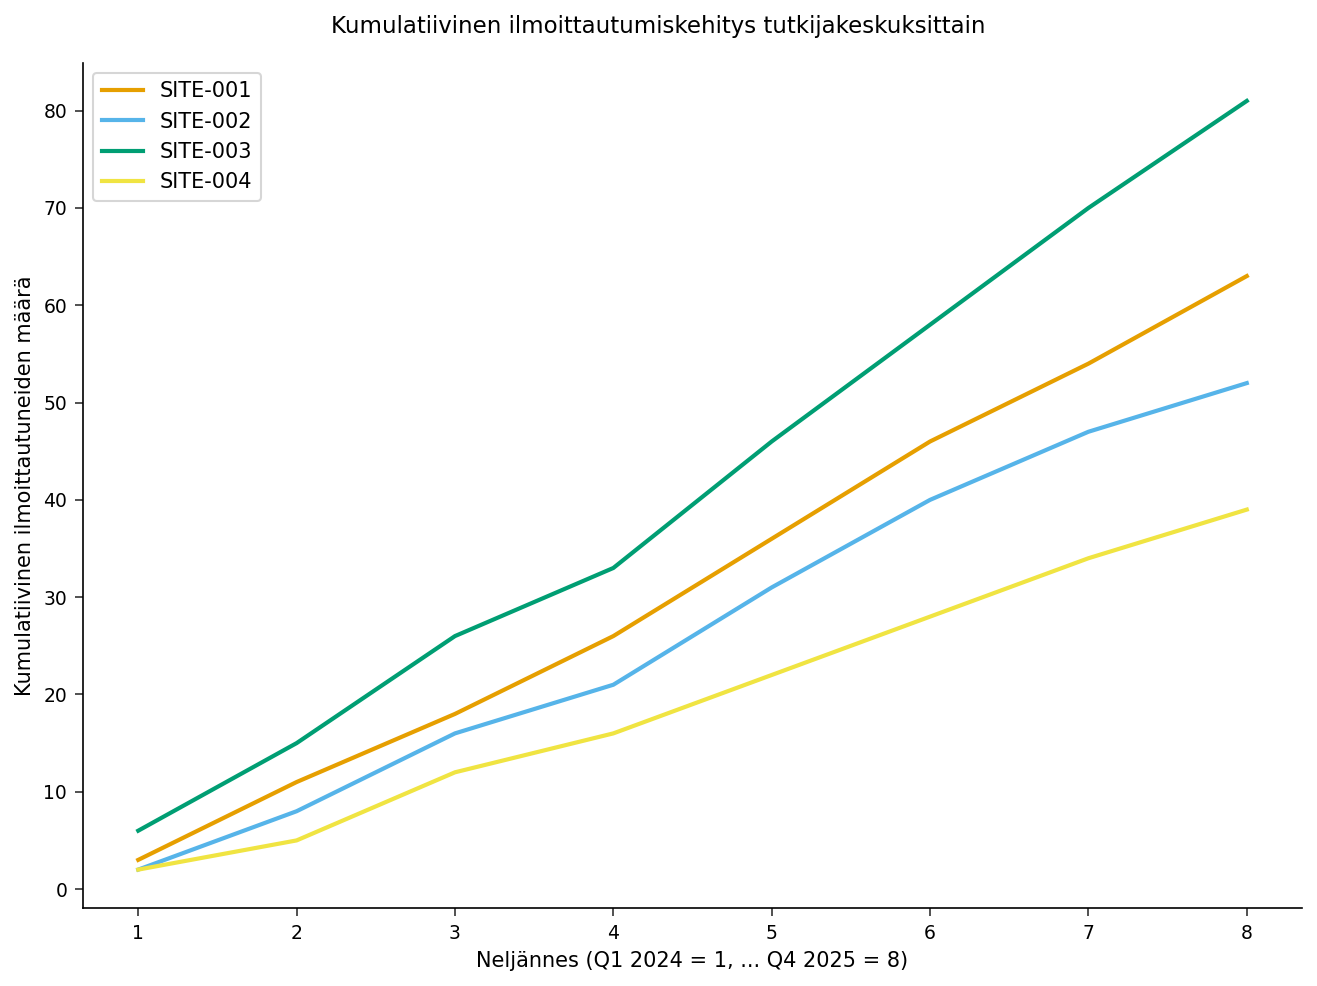

In [4]:
/* --------------------------------------------------------
   Quarterly cumulative-enrollment trajectory by site.
   Plotted against a quarter index (1..8) for a clean axis.
   -------------------------------------------------------- */
TIEDOT work.traj;
    ASETA work.enrollment_qtr;
    MUKAAN site_id;
    PIDÄ quarter_index 0;
    JOS first.site_id NIIN quarter_index = 0;
    quarter_index + 1;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS NIMIKE='Neljännes (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 ASTI 8 MUKAAN 1);
    YAXIS NIMIKE='Kumulatiivinen ilmoittautuneiden määrä';
    OTSIKKO 'Kumulatiivinen ilmoittautumiskehitys tutkijakeskuksittain';
SUORITA;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND requires the ID variable sorted within each
   BY group, so sort by site then quarter before converting.
   -------------------------------------------------------- */
PROSEDUURI LAJITTELE TIEDOT=work.enrollment_qtr;
    MUKAAN site_id quarter_date;
SUORITA;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convert quarterly enrollment to monthly estimates.

   FROM=QTR / TO=MONTH on the PROC statement set the input and
   output frequencies; PROC EXPAND interpolates each BY group
   (site) independently along the ID date.

   enrolled_count   -> METHOD=JOIN   (piecewise-linear; the flow
                       value stays non-negative between anchors)
   cumulative_enrolled -> METHOD=SPLINE (smooth monotone curve)
   -------------------------------------------------------- */
PROSEDUURI expand TIEDOT=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr ASTI=month;
    MUKAAN site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=LOPPU     METHOD=SPLINE;
SUORITA;


                             Neljännesvuosittaisten ilmoittautumisten perustaso alueittain                              




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                             Neljännesvuosittaisten ilmoittautumisten perustaso alueittain                              




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


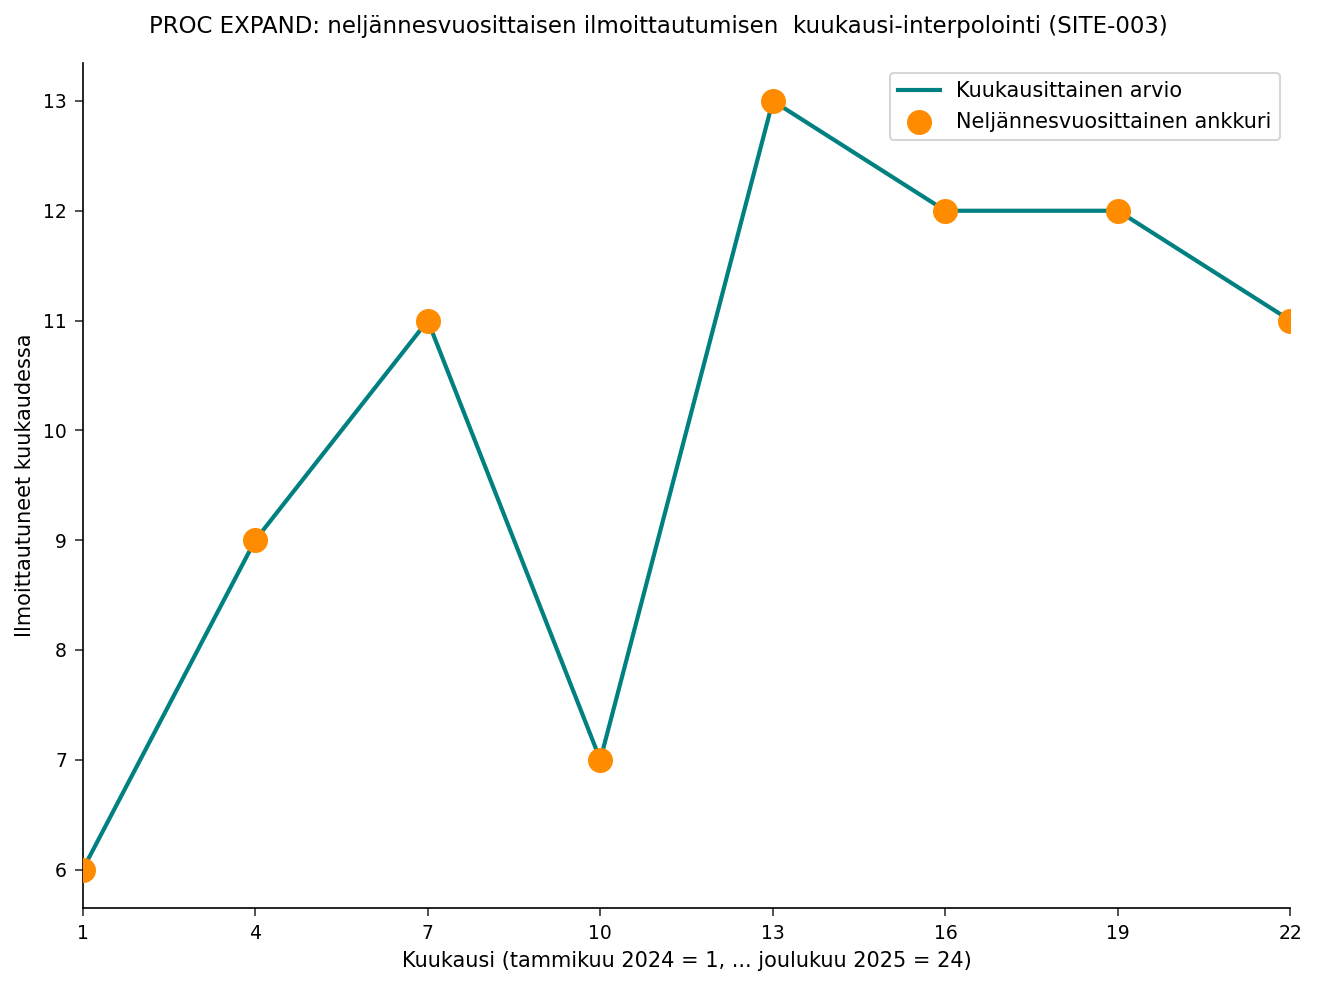

In [7]:
/* --------------------------------------------------------
   The ID variable now carries monthly dates. Re-format it and
   add a within-site month index (1..24) for plotting.
   -------------------------------------------------------- */
TIEDOT work.enrollment_monthly;
    ASETA work.enrollment_monthly;
    MUKAAN site_id;
    MUOTO month_date monyy7.;
    month_date = quarter_date;
    PIDÄ month_index 0;
    JOS first.site_id NIIN month_index = 0;
    month_index + 1;
    /* flag the quarter-anchor months (1, 4, 7, ...) */
    JOS mod(month_index - 1, 3) = 0 NIIN anchor = enrolled_count;
    MUUTEN anchor = .;
SUORITA;

/* Show the conversion for one site: interpolated monthly line
   passing through the original quarterly anchor points. */
PROSEDUURI SGPLOT TIEDOT=work.enrollment_monthly;
    MISSÄ site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Kuukausittainen arvio';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Neljännesvuosittainen ankkuri';
    XAXIS NIMIKE='Kuukausi (tammikuu 2024 = 1, ... joulukuu 2025 = 24)'
        integer VALUES=(1 ASTI 24 MUKAAN 3);
    YAXIS NIMIKE='Ilmoittautuneet kuukaudessa';
    OTSIKKO 'PROC EXPAND: neljännesvuosittaisen ilmoittautumisen '
        'kuukausi-interpolointi (SITE-003)';
SUORITA;


In [8]:
/* --------------------------------------------------------
   Join the monthly estimates to site metadata, then summarize
   monthly enrollment by region.
   -------------------------------------------------------- */
PROSEDUURI SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    VALITSE e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER MUKAAN s.region, e.site_id, e.month_date;
QUIT;

PROSEDUURI KESKIARVOT TIEDOT=work.enrollment_monthly_region n sum mean;
    LUOKKA region;
    MUUTTUJA monthly_estimate cumulative_estimate;
    NIMIKE region='Alue' monthly_estimate='Kuukausittainen arvio' cumulative_estimate='Kumulatiivinen arvio';
    TULOSTE out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.region_monthly_summary noobs NIMIKE;
    NIMIKE region='Alue' total_monthly_enrolled='Ilmoittautuneet yhteensä (kk)'
          avg_monthly_rate='Keskimääräinen kuukausitahti';
    OTSIKKO 'Kuukausittaiset arviot alueittain';
SUORITA;


                             Neljännesvuosittaisten ilmoittautumisten perustaso alueittain                              

                             Neljännesvuosittaisten ilmoittautumisten perustaso alueittain                              

                                                  The MEANS Procedure

                               Analysis Variable : monthly_estimate Kuukausittainen arvio

        Alue                      N Obs            Sum           Mean
        -------------------------------------------------------------
        EUROOPPA                     44    336.0000000      7.6363636
        POHJOIS_AMERIKKA             44    326.0000000      7.4090909
        -------------------------------------------------------------

                              Analysis Variable : cumulative_estimate Kumulatiivinen arvio

        Alue                      N Obs            Sum           Mean
        -------------------------------------------------------------
        EUR


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Tulkinta

PROC EXPAND muunsi **32 neljännesvuosittaista tietuetta** (4 keskusta x 8 neljännestä) **96 kuukausittaiseksi tietueeksi** frekvenssimuunnoksella kunkin keskuksen päivämäärän mukaisesti. Interpoloitu kuukausittainen aikasarja kulkee täsmälleen alkuperäisten neljännesvuosittaisten ankkuriarvojen kautta, kuten SITE-003:n kuvaaja osoittaa: oranssit pisteet ovat kahdeksan raportoitua neljännesvuosittaista lukumäärää ja turkoosi viiva on ne yhdistävä eritelty kuukausittainen arvio.

Kuukausitasolla nämä kaksi aluetta seuraavat toisiaan tiiviisti. Euroopassa keskiarvo on **7.64** ilmoittautunutta koehenkilöä keskusta ja kuukautta kohti ja Pohjois-Amerikassa **7.41**, ja alueelliset kuukausittaiset kokonaismäärät ovat **336** ja **326** koehenkilöä interpoloidulla aikavälillä. Koska `METHOD=JOIN` ei ekstrapoloi viimeisen neljännesvuosittaisen ankkurin ohi, viimeiset osittaisen neljänneksen kuukaudet eivät sisällä arviota ja ne jätetään pois kuukausittaisista keskiarvoista, mikä on varovainen valinta tulevaisuuden suunnittelussa.

Nämä kuukausittaiset ennusteet antavat kliiniselle toiminnalle mahdollisuuden siirtyä neljännesvuosittaisesta suunnittelutahdista kuukausittaiseen -- mitoittaa lääketoimituksia, aikatauluttaa seurantakäyntejä ja raportoida ilmoittautumista tietoturvan seurantalautakunnalle (Data Safety Monitoring Board) -- ilman että mitään tutkimuksen jo lukitsemia neljännesvuosittaisia lukuja tarvitsee esittää uudelleen.

---

In [9]:
/* --------------------------------------------------------
   Export monthly enrollment projections for downstream
   planning tools.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
SUORITA;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteuttaja: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>